In [1]:
using DifferentialEquations, LinearAlgebra, Plots

In [2]:
# Basis states
r = [0; 1]  # Assume |1>
g = [1; 0]  # Assume |0>

#Initial state
α = 1
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

ρ_0 = complex(kron(ψ_a,ψ_1) * kron(ψ_a,ψ_1)')

4×4 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im

In [3]:
struct parameters
    Ω::Float64     
    γ_Decay::Float64     
    γ_dephase::Float64
    V_nn::Float64     
 end

In [69]:
function (p::parameters)(t)
    Δ0 = 3000
    δ = -1
    return (Δ0+δ*t,p.Ω, p.γ_Decay, p.γ_dephase, p.V_nn)
end

p = parameters(20,1,1,-2000)

parameters(20.0, 1.0, 1.0, -2000.0)

In [107]:
# Define the ODE system
function master_eqn(dρ, ρ, p, t)
    # Extract ρ_matrix and Δ_t from the state vector
    ρ_matrix = reshape(ρ[1:16], 4, 4)  # Reshape first 16 elements back into a 4x4 matrix
    Δ_t = ρ[17]                         # Last element is Δ_t

    # 2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    I = [1 0; 0 1]
    σ_minus = [0 0; 1 0]
    σ_plus = [0 1; 0 0]
    σ_z = [1 0; 0 -1]

    # Parameters
    Δ_t_current, Ω, γ_Decay, γ_dephase, V_nn = p(t)
    δ = -1

    # Hamiltonian
    H = Ω/2 .* kron(I, σ_x) + Δ_t_current .* kron(I, n) + V_nn .* kron(n, n)
    l_decay = γ_Decay .* (kron(I, σ_minus) * ρ_matrix * kron(I, σ_plus) - 0.5 .* (kron(I, σ_plus) * kron(I, σ_minus) * ρ_matrix + ρ_matrix * kron(I, σ_plus) * kron(I, σ_minus)))
    l_dephase = γ_dephase .* (kron(I, σ_z) * ρ_matrix * kron(I, σ_z) - ρ_matrix)

    # Update dρ
    dρ[1:16] .= vec(-1im .* (H * ρ_matrix - ρ_matrix * H) + l_decay + l_dephase)
    #dρ[1:16] = vec(dρ_matrix)  # Flatten the matrix back into the state vector
    dρ[17] = δ  # Δ_t does not dynamically evolve

end




# Prepare the expanded initial condition vector
ρ_0_expanded = [vec(ρ_0); p(0)[1]]  # Append initial Δ_t

# Time span and solve the problem
tspan = (0.0, 2000.0)
eqn = ODEProblem(master_eqn, ρ_0_expanded, tspan, p)
sol = solve(eqn, Tsit5(), saveat=1)
println(sol[end])

ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0005304460837008173 + 0.0im, -0.011496936457737422 - 0.0002575848289714885im, 0.0 + 0.0im, 0.0 + 0.0im, -0.011496936457737422 + 0.0002575848289714885im, 0.9994695539162989 + 0.0im, 999.9999999998929 + 0.0im]


In [108]:
ρ = [reshape(u[1:end-1],4,4) for u in sol.u]
println(tr(ρ[end]))

0.9999999999999997 + 0.0im


In [109]:
# for (t, ρ) in zip(sol.t, ρ)
#     println("Time: $t, Trace: $(tr(ρ))")
# end

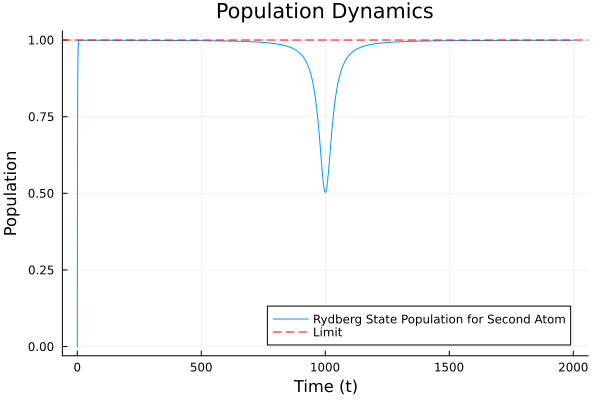

In [115]:
# Extracting populations from the solution
n = [0 0; 0 1]
I = [1 0; 0 1]

rydberg_populations = []

for i in ρ
    a = tr(kron(I,n)*i)
    push!(rydberg_populations, a)
end

# Plotting the Rydberg state population over time
plot(sol.t, rydberg_populations, label="Rydberg State Population for Second Atom", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")
hline!([1],color=:red,linestyle=:dash,label="Limit")


In [116]:
sol.u[end]

17-element Vector{ComplexF64}:
                   0.0 + 0.0im
                   0.0 + 0.0im
                   0.0 + 0.0im
                   0.0 + 0.0im
                   0.0 + 0.0im
                   0.0 + 0.0im
                   0.0 + 0.0im
                   0.0 + 0.0im
                   0.0 + 0.0im
                   0.0 + 0.0im
 0.0005304460837008173 + 0.0im
 -0.011496936457737422 - 0.0002575848289714885im
                   0.0 + 0.0im
                   0.0 + 0.0im
 -0.011496936457737422 + 0.0002575848289714885im
    0.9994695539162989 + 0.0im
     999.9999999998929 + 0.0im

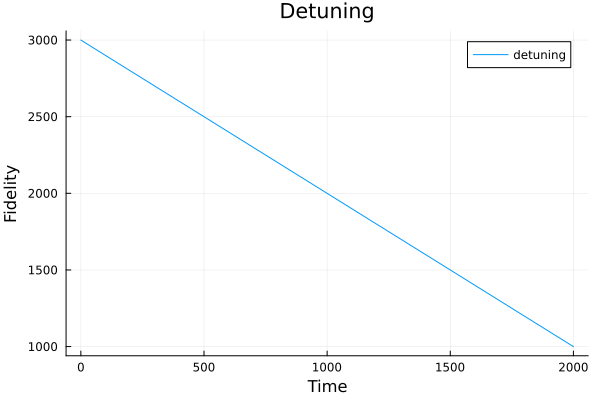

In [117]:
detuning = [u[end] for u in sol.u]
plot(time,real(detuning),label="detuning",xaxis="Time",yaxis="Fidelity",title="Detuning")

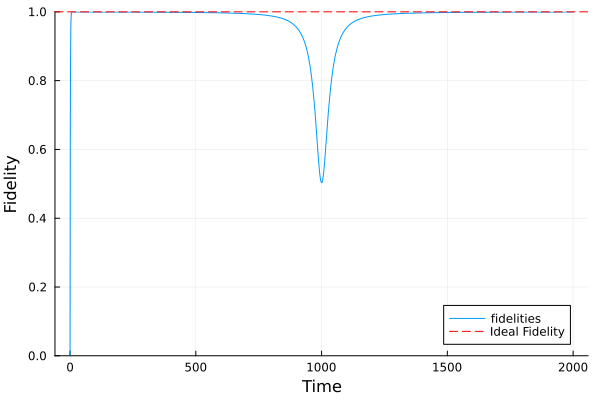

In [118]:
ψ_ideal = α*kron(r,r) + β*kron(g,g)

fidelities = []
time = []
for (t,i) in zip(sol.t,ρ)
    fidelity = ψ_ideal' * i * ψ_ideal
    push!(fidelities,fidelity)
    push!(time,t)
end

plot(time,real(fidelities),label="fidelities",xaxis="Time",yaxis="Fidelity",ylim=(0,1))
hline!([1], color=:red, linestyle=:dash, label="Ideal Fidelity")